<a href="https://colab.research.google.com/github/bidallei/MIAAD-UACJ/blob/main/EjemploRegularizacion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import os, random
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras import models, layers, regularizers
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical
from tensorflow.keras import backend as K
from sklearn.model_selection import train_test_split

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


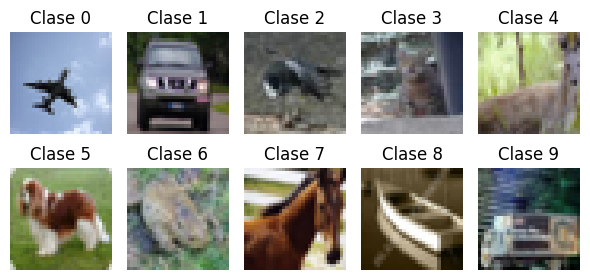

In [2]:
(X_train, y_train), (X_test, y_test) = cifar10.load_data()
X_train = X_train.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0
y_train_cat = to_categorical(y_train, 10)
y_test_cat = to_categorical(y_test, 10)

# Dividir los datos de entrenamiento para obtener el conjunto de validación
X_train, X_val, y_train_cat, y_val_cat = train_test_split(
    X_train, y_train_cat, test_size=0.1, random_state=42, stratify=y_train
)

# Diccionario de clases
class_names = {
    0: "Airplane", 1: "Automobile", 2: "Bird", 3: "Cat", 4: "Deer",
    5: "Dog", 6: "Frog", 7: "Horse", 8: "Ship", 9: "Truck"
}

y_train_labels = np.argmax(y_train_cat, axis=1)


plt.figure(figsize=(6,3))
for digit in range(10):
  idx = np.where(y_train_labels == digit)[0][0]

  plt.subplot(2, 5, digit+1)
  plt.imshow(X_train[idx], cmap='gray')
  plt.title(f"Clase {digit}")
  plt.axis('off')

plt.tight_layout()
plt.show()

In [3]:
def build_model(dropout_rate=0.0, l2_lambda=0.0):
    reg = regularizers.l2(l2_lambda) if l2_lambda > 0 else None
    model = models.Sequential([
        layers.Input(shape=(32, 32, 3)),
        layers.Conv2D(32, (3,3), activation='relu', padding='same',
                      kernel_regularizer=reg),
        layers.Conv2D(32, (3,3), activation='relu', padding='same',
                      kernel_regularizer=reg),
        layers.MaxPooling2D((2,2)),
        layers.Dropout(dropout_rate),

        layers.Conv2D(64, (3,3), activation='relu',
                      kernel_regularizer=reg),
        layers.Conv2D(64, (3,3), activation='relu',
                      kernel_regularizer=reg),
        layers.MaxPooling2D((2,2)),
        layers.Dropout(dropout_rate),

        layers.Flatten(),
        layers.Dense(128, activation='relu',
                      kernel_regularizer=reg),
        layers.Dropout(dropout_rate),
        layers.Dense(10, activation='softmax')
    ])
    model.compile(optimizer='adam',
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])

    return model

# Hiperparámetros
EPOCHS = 50
BATCH = 64

In [4]:
# Entrenamiento: modelo SIN regularización
K.clear_session
model_base = build_model(dropout_rate=0.0, l2_lambda=0.0)
print(model_base.summary())

hist_base = model_base.fit(
    X_train, y_train_cat,
    epochs=EPOCHS, batch_size=BATCH,
    validation_data=(X_val, y_val_cat),
    verbose=2
)

test_loss_base, test_acc_base = model_base.evaluate(X_test, y_test_cat, verbose=0)
print(f'[SIN REG] Test accuracy: {test_acc_base * 100:.2f}% | Test loss: {test_loss_base:.4f}')

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 12, 12, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       295,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 361,898 (1.38 MB)

 Trainable params: 361,898 (1.38 MB)

 Non-trainable params: 0 (0.00 B)

None
Epoch 1/50
704/704 - 12s - 18ms/step - accuracy: 0.4586 - loss: 1.5001 - val_accuracy: 0.5394 - val_loss: 1.3187
Epoch 2/50
704/704 - 4s - 6ms/step - accuracy: 0.6191 - loss: 1.0772 - val_accuracy: 0.6268 - val_loss: 1.0792
Epoch 3/50
704/704 - 4s - 6ms/step - accuracy: 0.6880 - loss: 0.8921 - val_accuracy: 0.6912 - val_loss: 0.8851
Epoch 4/50
704/704 - 4s - 6ms/step - accuracy: 0.7281 - loss: 0.7759 - val_accuracy: 0.6892 - val_loss: 0.9114
Epoch 5/50
704/704 - 4s - 6ms/step - accuracy: 0.7588 - loss: 0.6904 - val_accuracy: 0.7334 - val_loss: 0.7523
Epoch 6/50
704/704 - 4s - 6ms/step - accuracy: 0.7849 - loss: 0.6143 - val_accuracy: 0.7216 - val_loss: 0.8364
Epoch 7/50
704/704 - 4s - 6ms/step - accuracy: 0.8078 - loss: 0.5550 - val_accuracy: 0.7524 - val_loss: 0.7190
Epoch 8/50
704/704 - 4s - 6ms/step - accuracy: 0.8266 - loss: 0.4979 - val_accuracy: 0.7526 - val_loss: 0.7501
Epoch 9/50
704/704 - 4s - 6ms/step - accuracy: 0.8422 - loss: 0.4437 - val_accuracy: 0.7532 - val_loss: 0

In [7]:
# Entrenamiento: modelo CON regularización
K.clear_session

DROPOUT = 0.3
L2_LAMBDA = 5e-4

model_reg = build_model(dropout_rate=DROPOUT, l2_lambda=L2_LAMBDA)
print(model_reg.summary())

hist_reg = model_reg.fit(
    X_train, y_train_cat,
    epochs=EPOCHS, batch_size=BATCH,
    validation_data=(X_val, y_val_cat),
    verbose=2
)

test_loss_reg, test_acc_reg = model_reg.evaluate(X_test, y_test_cat, verbose=0)
print(f'[CON REG] Test accuracy: {test_acc_reg * 100:.2f}% | Test loss: {test_loss_reg:.4f}')

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_12 (Conv2D)              │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 12, 12, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │       295,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 361,898 (1.38 MB)

 Trainable params: 361,898 (1.38 MB)

 Non-trainable params: 0 (0.00 B)

None
Epoch 1/50
704/704 - 15s - 21ms/step - accuracy: 0.4145 - loss: 1.7137 - val_accuracy: 0.5516 - val_loss: 1.3579
Epoch 2/50
704/704 - 4s - 6ms/step - accuracy: 0.5502 - loss: 1.3785 - val_accuracy: 0.6216 - val_loss: 1.1936
Epoch 3/50
704/704 - 4s - 6ms/step - accuracy: 0.6013 - loss: 1.2609 - val_accuracy: 0.6590 - val_loss: 1.1135
Epoch 4/50
704/704 - 4s - 6ms/step - accuracy: 0.6332 - loss: 1.1888 - val_accuracy: 0.6778 - val_loss: 1.0542
Epoch 5/50
704/704 - 4s - 6ms/step - accuracy: 0.6607 - loss: 1.1373 - val_accuracy: 0.7118 - val_loss: 0.9956
Epoch 6/50
704/704 - 4s - 6ms/step - accuracy: 0.6787 - loss: 1.0872 - val_accuracy: 0.7172 - val_loss: 0.9705
Epoch 7/50
704/704 - 4s - 6ms/step - accuracy: 0.6921 - loss: 1.0555 - val_accuracy: 0.7102 - val_loss: 0.9774
Epoch 8/50
704/704 - 4s - 6ms/step - accuracy: 0.6999 - loss: 1.0356 - val_accuracy: 0.7440 - val_loss: 0.9241
Epoch 9/50
704/704 - 4s - 6ms/step - accuracy: 0.7095 - loss: 1.0152 - val_accuracy: 0.7430 - val_loss: 0

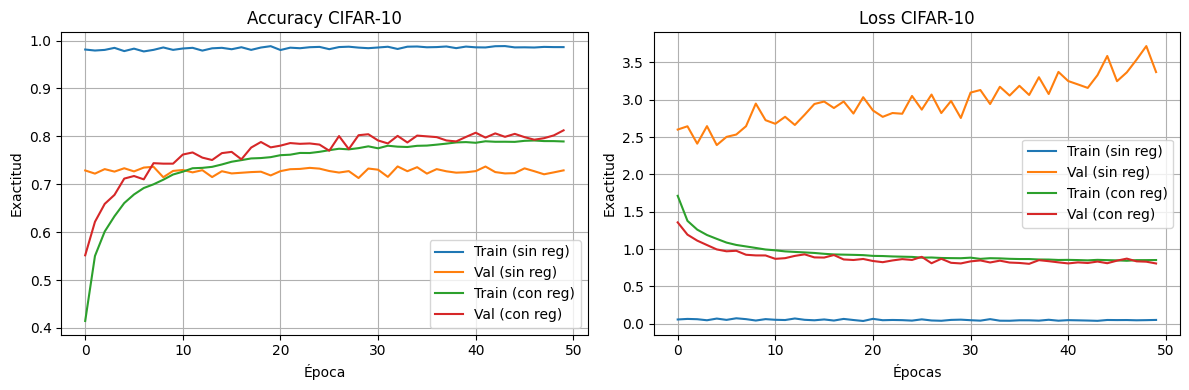

In [8]:
def plot_history(h1, h2, title_sufix=""):
  # Accuracy
  plt.figure(figsize=(12, 4))
  plt.subplot(1, 2, 1)
  plt.plot(h1.history['accuracy'], label='Train (sin reg)')
  plt.plot(h1.history['val_accuracy'], label='Val (sin reg)')
  plt.plot(h2.history['accuracy'], label='Train (con reg)')
  plt.plot(h2.history['val_accuracy'], label='Val (con reg)')
  plt.title(f'Accuracy {title_sufix}')
  plt.xlabel('Época'); plt.ylabel('Exactitud'); plt.legend(); plt.grid(True)

  # Loss
  plt.subplot(1, 2, 2)
  plt.plot(h1.history['loss'], label='Train (sin reg)')
  plt.plot(h1.history['val_loss'], label='Val (sin reg)')
  plt.plot(h2.history['loss'], label='Train (con reg)')
  plt.plot(h2.history['val_loss'], label='Val (con reg)')
  plt.title(f'Loss {title_sufix}')
  plt.xlabel('Épocas'); plt.ylabel('Exactitud'); plt.legend(); plt.grid(True)

  plt.tight_layout()
  plt.show()

plot_history(hist_base, hist_reg, title_sufix="CIFAR-10")